LOGICAL INTUITION BEHIND GAUSSION_NB

Posterior(Male) =[P(M)*P(H|M)*P(W|M)*P(FS|M)]/Evidence
                        

Probability Density function 
 = 1/sqrt(2pi * sigma^2) * exp(-(X-mu)^2/2*sigma^2)
 $$f(x) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$
 
 

$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{1}{2}(\frac{x-\mu}{\sigma})^2\right)$

$(f(x) = \frac{1}{\sqrt{2\pi \sigma^2}} \exp(-\frac{(x-mu)^2}{2\sigma^2}))$

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


url='/kaggle/input/heart-attack-analysis-prediction-dataset/heart.csv'
df = pd.read_csv('Datasets/heart.csv')
df
df.isnull().sum()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool

In [ ]:
df[df.duplicated()]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [ ]:
df.drop_duplicates(keep='first',inplace=True)

In [ ]:
df[df.duplicated()]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output


Gender Categorization

Number of people having sex as 1 are 206 and number of people having sex as 0 are 96


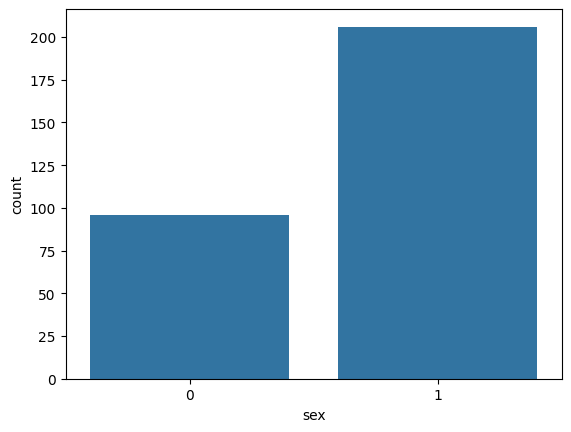

In [ ]:
x= (df.sex.value_counts())
print(f'Number of people having sex as 1 are {x[1]} and number of people having sex as 0 are {x[0]}')
p = sns.countplot(data = df, x= 'sex')
plt.show()

cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64


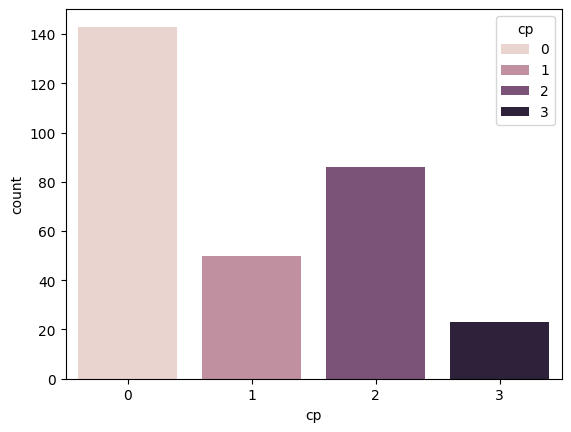

In [ ]:
x= (df.cp.value_counts())
print(x)
p = sns.countplot(data = df, x= 'cp',hue='cp')
plt.show()

AGE DISTRIBUTION

<Figure size 1000x1000 with 0 Axes>

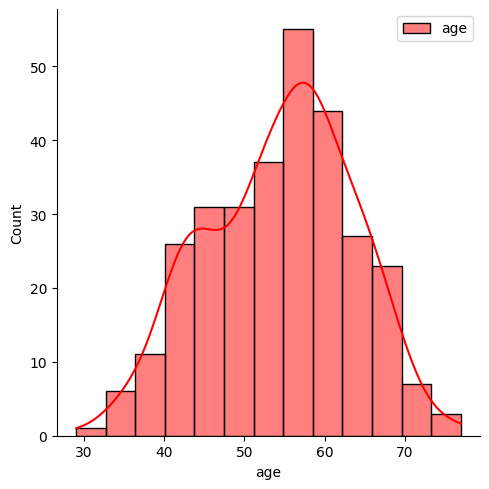

In [ ]:
plt.figure(figsize=(10,10))
sns.displot(df.age , color = 'red', label = 'age' , kde = True)
plt.legend()

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='str')

<Figure size 1000x1000 with 0 Axes>

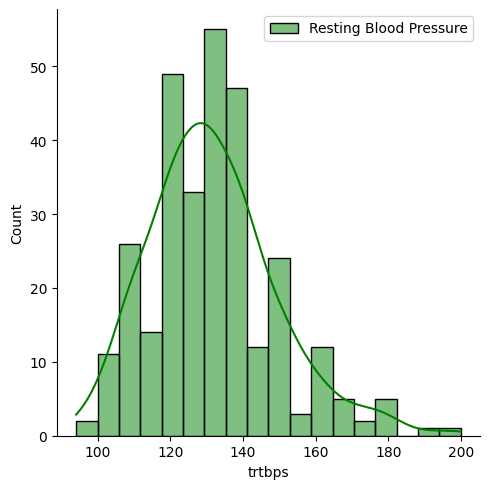

In [ ]:
plt.figure(figsize=(10,10))
sns.displot(df.trtbps,color = 'green',kde=True,label='Resting Blood Pressure')
plt.legend()

C:\Users\HP\AppData\Local\Temp\ipykernel_12876\3716650988.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['output'] == 0]['age'],color='red',kde = True)
C:\Users\HP\AppData\Local\Temp\ipykernel_12876\3716650988.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['output'] == 1]['

Text(0.5, 1.0, 'Attack Vs Age')

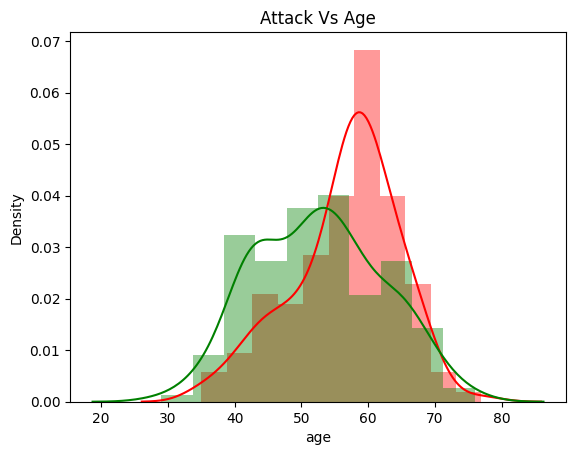

In [ ]:
plt.Figure(figsize=(10,10))
sns.distplot(df[df['output'] == 0]['age'],color='red',kde = True)
sns.distplot(df[df['output'] == 1]['age'],color='green',kde = True)
plt.title('Attack Vs Age'
          )

In [ ]:
y = df.iloc[:,-1].values
x= df.iloc[:,1: -1].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.25)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb =GaussianNB()
gnb.fit(X_train,y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [ ]:
y_pred = gnb.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.868421052631579

In [ ]:
gnb.predict_proba(X_test)

array([[9.71360303e-01, 2.86396973e-02],
       [8.60275812e-01, 1.39724188e-01],
       [8.24758619e-03, 9.91752414e-01],
       [9.97675838e-01, 2.32416166e-03],
       [3.50784063e-03, 9.96492159e-01],
       [4.20284378e-03, 9.95797156e-01],
       [2.18239260e-01, 7.81760740e-01],
       [9.99419044e-01, 5.80956201e-04],
       [9.99922046e-01, 7.79540337e-05],
       [1.31882891e-01, 8.68117109e-01],
       [1.02795668e-01, 8.97204332e-01],
       [9.99862967e-01, 1.37032980e-04],
       [3.77633714e-03, 9.96223663e-01],
       [9.61355861e-01, 3.86441393e-02],
       [4.60088582e-04, 9.99539911e-01],
       [3.27411790e-03, 9.96725882e-01],
       [2.71655025e-04, 9.99728345e-01],
       [9.99891239e-01, 1.08761189e-04],
       [9.99063284e-01, 9.36715941e-04],
       [9.99798193e-01, 2.01806967e-04],
       [1.52430511e-01, 8.47569489e-01],
       [9.99089595e-01, 9.10405162e-04],
       [9.19315402e-01, 8.06845979e-02],
       [1.61934489e-02, 9.83806551e-01],
       [2.596804